In [2]:
import numpy as np
from IPython.core.interactiveshell import InteractiveShell as IS
IS.ast_node_interactivity = "all"
import matplotlib.pyplot as plt
from config import *
plt.rcParams.update({
    'figure.dpi': 200,
    # 统一字体：SimHei支持中文，Times兼容英文负号（无冲突）
    'font.family': ['SimHei', 'Times New Roman'],
    'font.size': 20,
    'legend.fontsize': 18,
    'lines.linewidth': 5,
    'savefig.bbox': 'tight',
    # 核心：关闭Unicode负号，用ASCII减号（解决负号显示）
    'axes.unicode_minus': False
})

# SVM

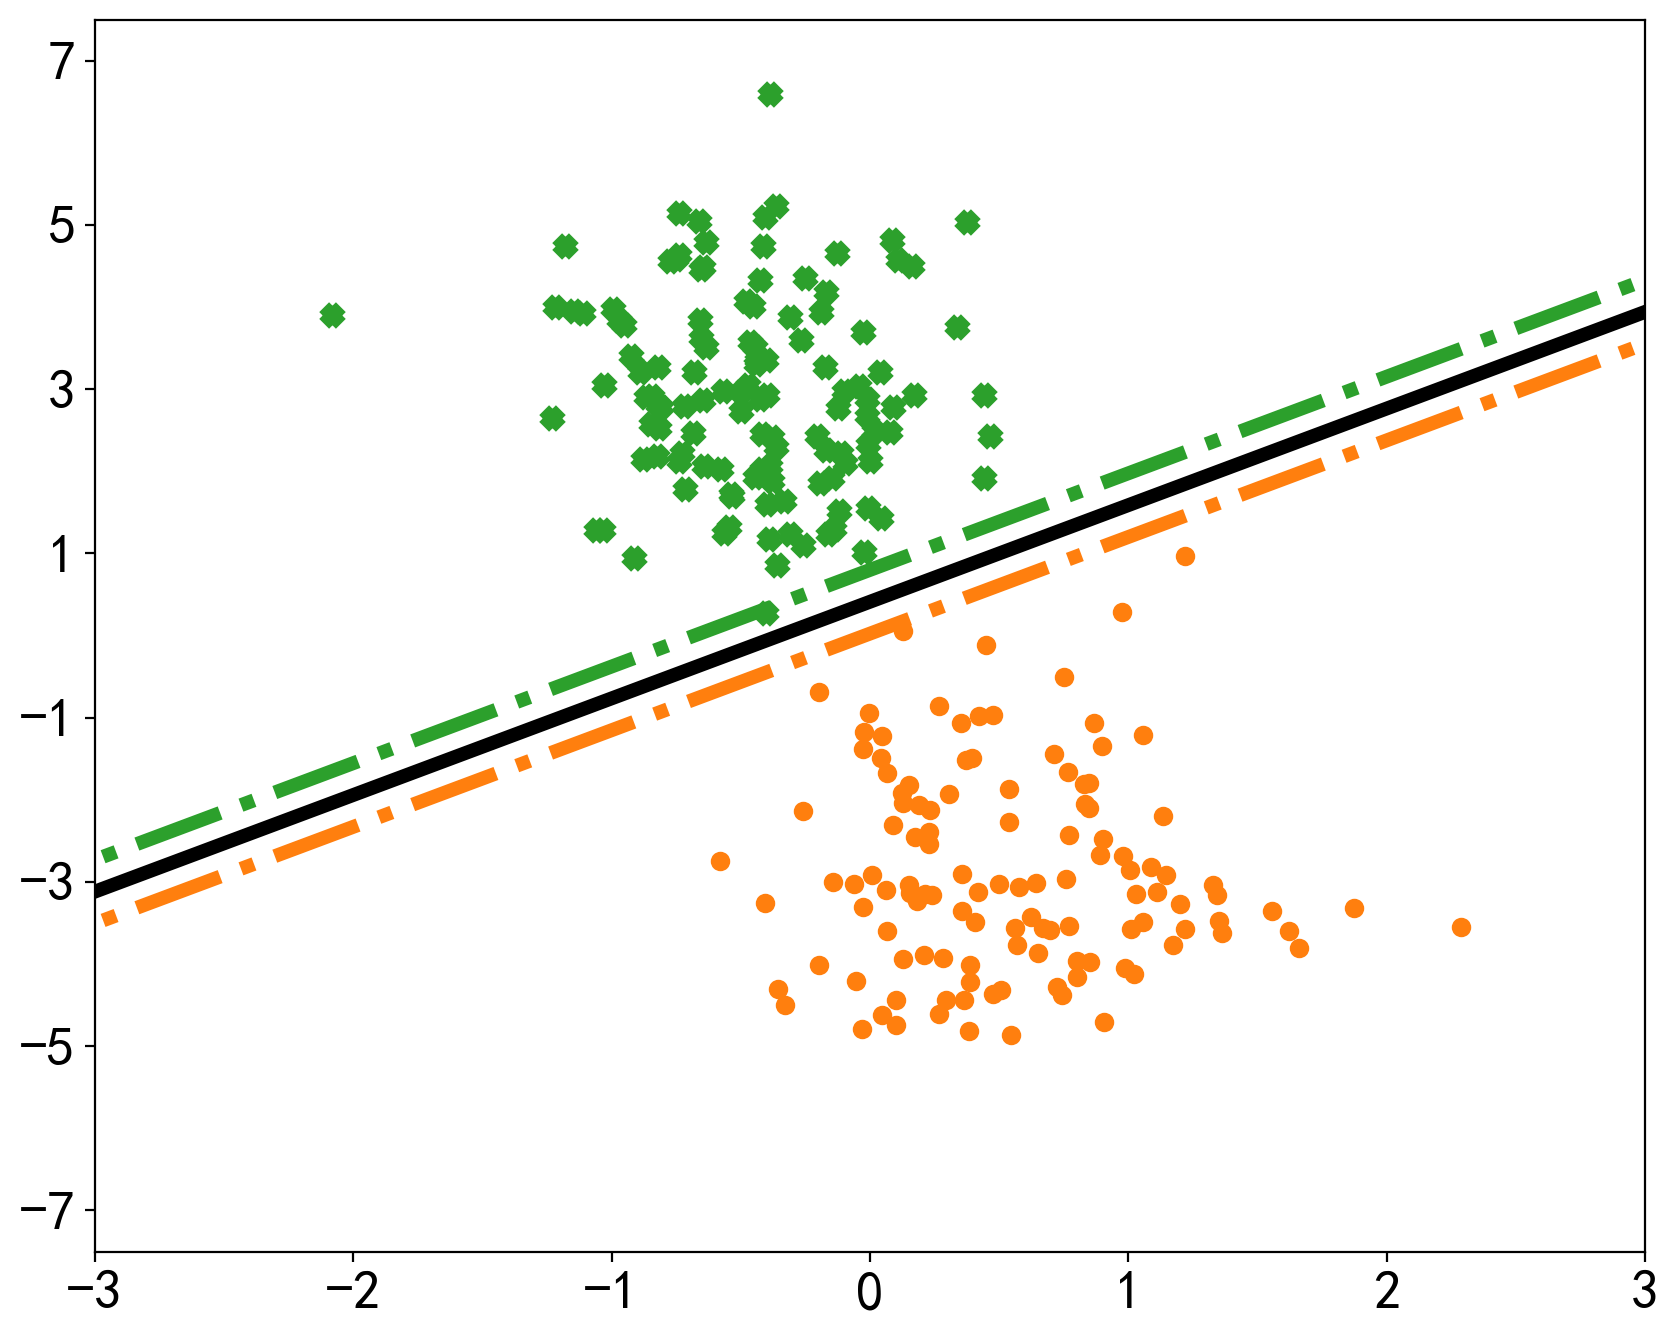

In [7]:
num=300
np.random.seed(num)
X1=np.random.multivariate_normal(mean=(0.5,-3),cov=np.diag([0.2,1.5]),size=int(num*0.8/2))
X2=np.random.multivariate_normal(mean=(-0.5,3),cov=np.diag([0.2,1.5]),size=int(num*0.8/2))
y_norm=np.ones(int(num*0.8))
y_norm[-int(num*0.8/2):]=2
X3=np.random.multivariate_normal(mean=(0,0),cov=[[1,-0.8],[-0.8,1]],size=int(num*0.2))
y_abnorm=np.random.randint(1,3,int(num*0.2))
# y=np.r_[y_norm,y_abnorm]
# X=np.row_stack([X1,X2,X3])
X=np.row_stack([X1,X2])
y=y_norm.copy()

w=2.5
distance=(abs(w*X[:,0]-X[:,1]))/np.sqrt(2.5)
tau=0.5
q=tau/(1+tau)
distance1=np.quantile(distance[y==1],q)
distance1
distance2=np.quantile(distance[y==2],q)
distance2
abs_dist=(distance1+distance2)/2
abs_dist

from sklearn.svm import SVC
s=SVC(kernel='linear')
s=s.fit(X,y)
_w=s.coef_.flatten()
_b=s.intercept_
w_svm=_w[0]/-_w[1]
b_svm=_b/-_w[1]

distance_svm=abs(w_svm*X[:,0]+b_svm-X[:,1])/np.sqrt(w_svm)
min_dist=(min(distance_svm[y==1])+min(distance_svm[y==2]))/2

fz=20
fig=plt.figure(figsize=(10,8))
plt.xticks(range(-3,4),range(-3,4),size=fz)
plt.yticks(np.arange(-7,8).tolist()[::2],np.arange(-7,8).tolist()[::2],size=fz)
plt.scatter(X[:,0][y==1],X[:,1][y==1],marker='o',c='C1')#c='C1'
plt.scatter(X[:,0][y==2],X[:,1][y==2],marker='x',c='C2')#c='C2'
x1_pin=np.linspace(-4,4,100)
x2_pin=w*x1_pin
l_w=3
# plt.plot(x1_pin,x2_pin,c='black',lw=l_w,color='k',label=r'$Pinball$')
# plt.plot(x1_pin-abs_dist,x2_pin,c='black',ls='--',lw=l_w)
# plt.plot(x1_pin+abs_dist,x2_pin,c='black',ls='--',lw=l_w)

plt.plot(x1_pin,w_svm*x1_pin+b_svm,c='black',label=r'$Hinge$')
plt.plot(x1_pin,w_svm*x1_pin+b_svm-min_dist, ls='-.', c="C1")
plt.plot(x1_pin,w_svm*x1_pin+b_svm+min_dist, ls='-.', c="C2")
plt.xlim([-3,3]);
plt.ylim([-7.5,7.5])
# plt.legend(fontsize=fz);
fig.savefig(generateFilePath("2SVM"), bbox_inches='tight', dpi=200);

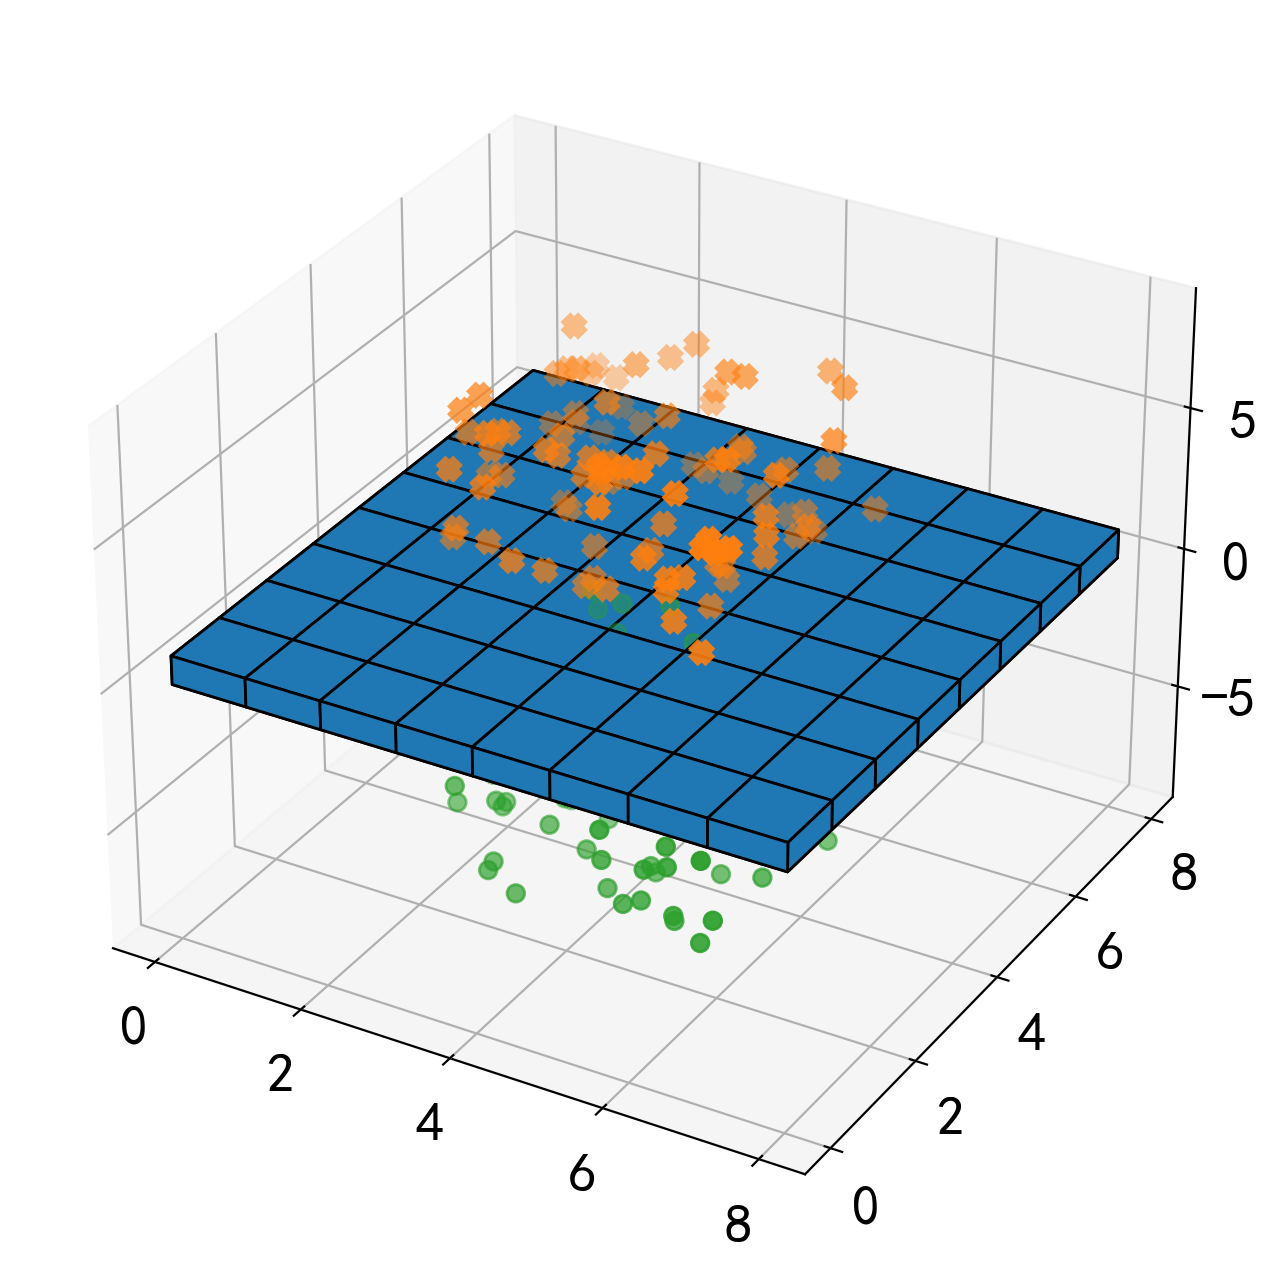

In [6]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # 正确用法
x, y, z = np.indices((8, 8, 8))
voxelarray = (x < 8) & (y < 8) & (z < 1)

n = 100
rng = np.random.default_rng()
xs = rng.uniform(2, 6, n)
ys = rng.uniform(2, 6, n)
zs = rng.uniform(2, 8, n)
ax.voxels(voxelarray, edgecolor='k', shade=False)
ax.scatter(xs, ys, zs, marker='x', s=40)
zs = rng.uniform(-8, -2, n)
ax.scatter(xs, ys, zs, marker='o', s=40);
fig.savefig(generateFilePath("3SVM"), bbox_inches='tight', dpi=200);

# kernel

SVC(gamma=2, kernel='linear')

(-1.985, 2.085, -3.085, 3.185)

(-3.0, 3.0)

(-3.0, 3.0)

Text(0.5, 1.0, 'linear')

...

SVC(gamma=2)

(-1.985, 2.085, -3.085, 3.185)

(-3.0, 3.0)

(-3.0, 3.0)

Text(0.5, 1.0, 'rbf')

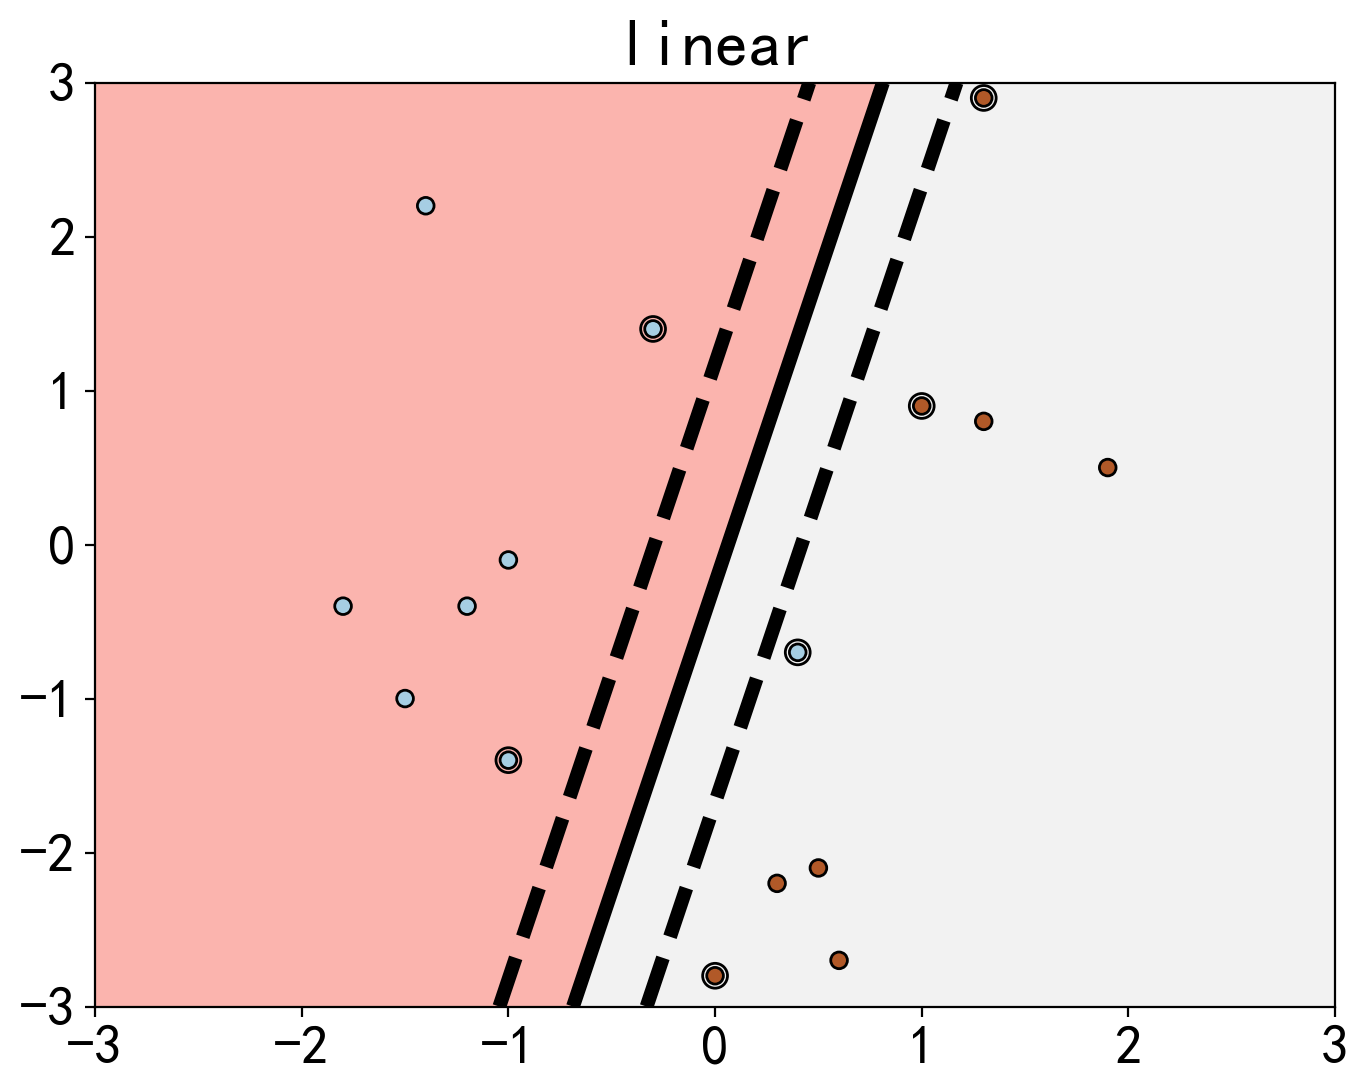

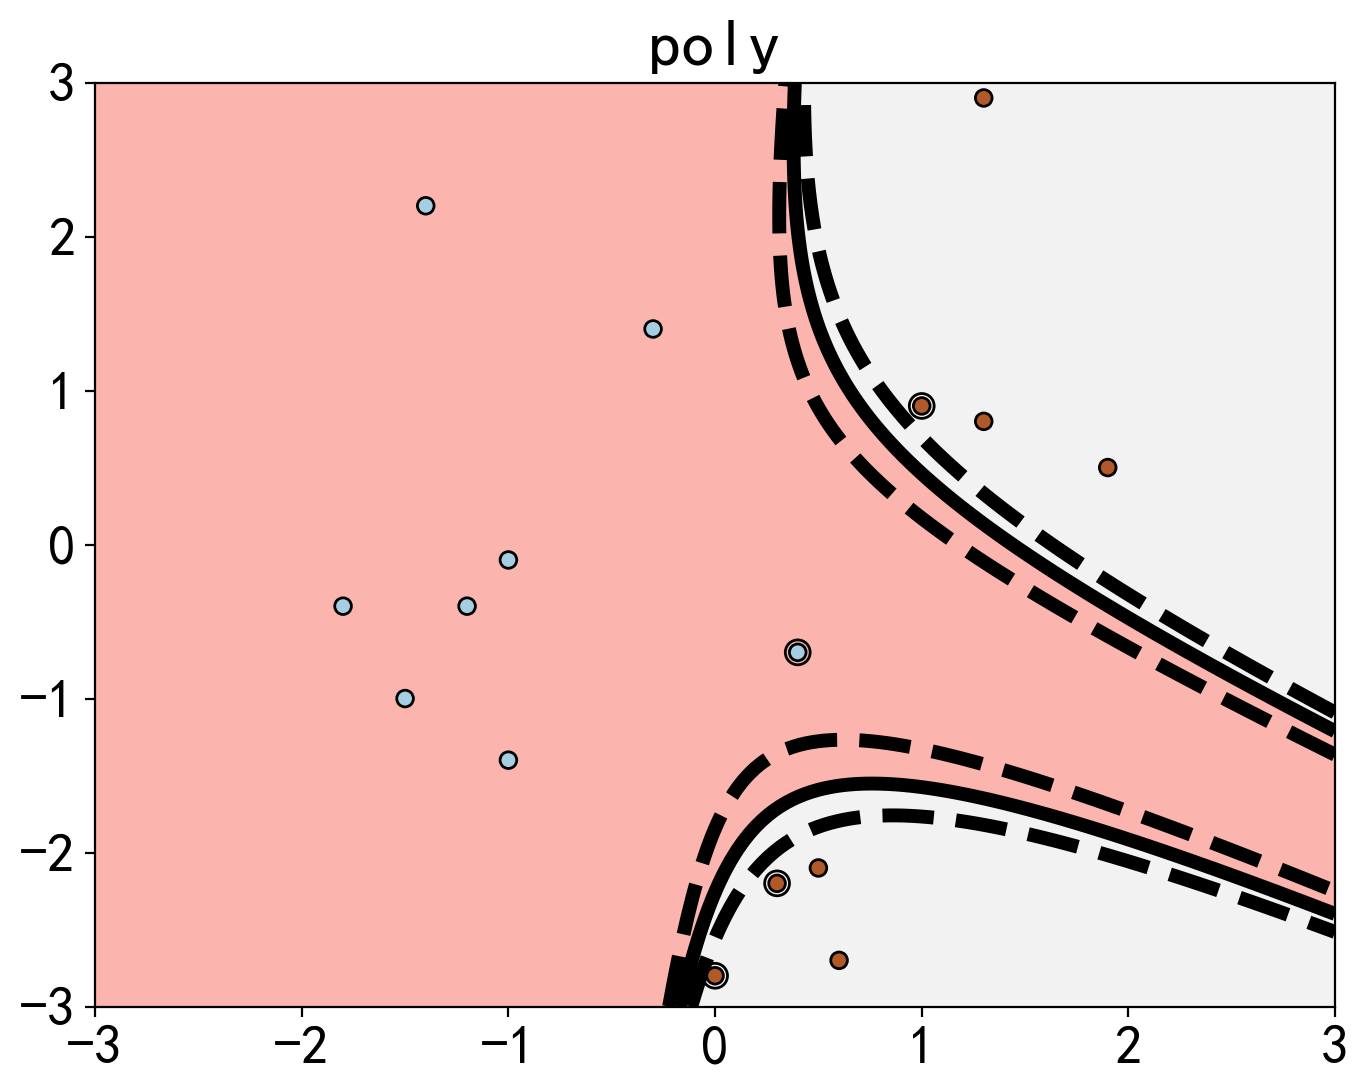

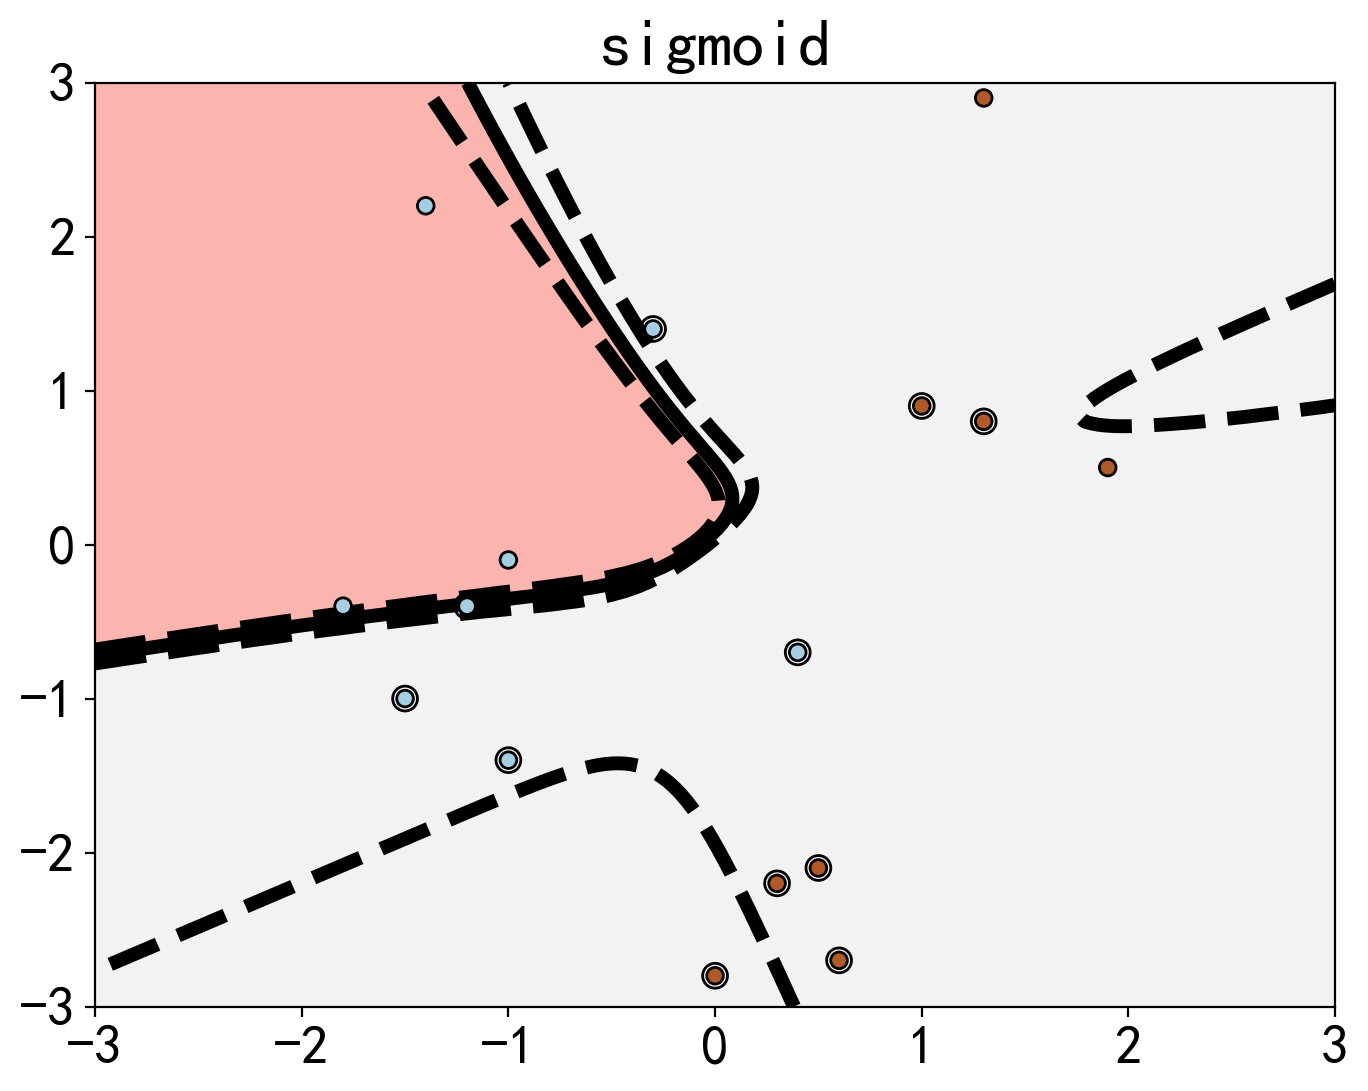

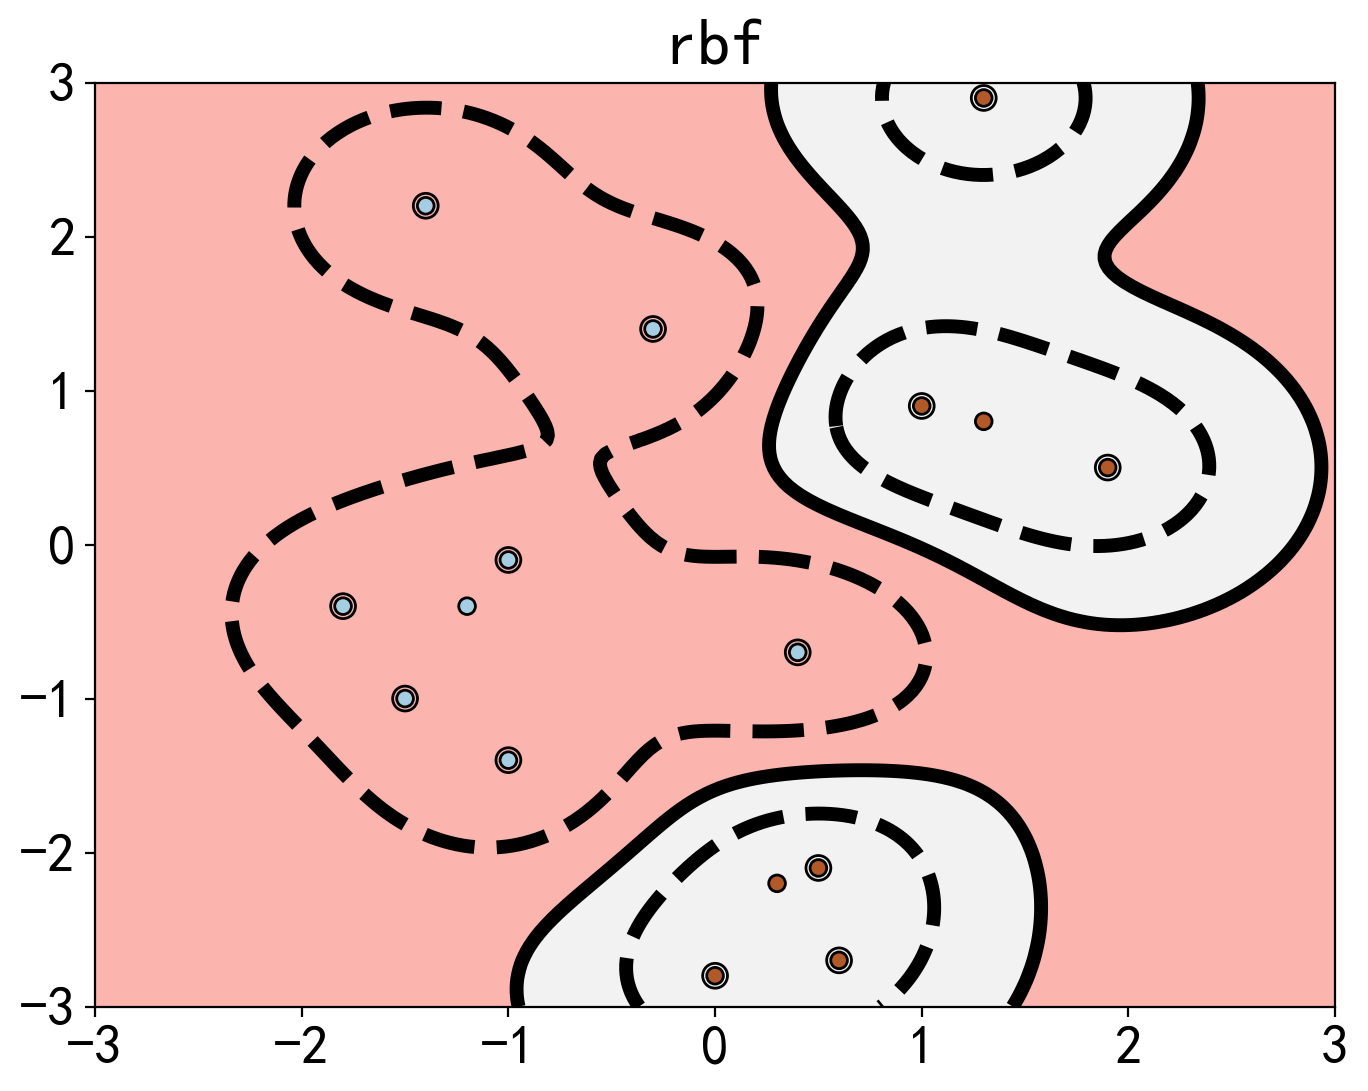

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm


X = np.c_[
    (0.4, -0.7),
    (-1.5, -1),
    (-1.8, -0.4),
    (-1.0, -1.4),
    (-1.0, -0.1),
    (-1.2, -0.4),
    (-0.3, 1.4),
    (-1.4, 2.2),
    (1, 0.9),
    # --
    (1.3, 0.8),
    (1.9, 0.5),
    (0.3, -2.2),
    (0.5, -2.1),
    (0.6, -2.7),
    (0, -2.8),
    (1.3, 2.9),
].T
Y = [0] * 8 + [1] * 8

# figure number
fignum = 1

# fit the model
for i, kernel in enumerate(("linear", "poly", "sigmoid","rbf")):
    clf = svm.SVC(kernel=kernel, gamma=2)
    clf.fit(X, Y)

    fig = plt.figure(figsize=(8, 6))
    plt.scatter(
        clf.support_vectors_[:, 0],
        clf.support_vectors_[:, 1],
        s=80,
        facecolors="none",
        zorder=10,
        edgecolors="k",
    )
    plt.scatter(X[:, 0], X[:, 1], c=Y, zorder=10, cmap=plt.cm.Paired, edgecolors="k")

    plt.axis("tight")
    x_min = -3
    x_max = 3
    y_min = -3
    y_max = 3

    XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
    Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(XX.shape)
    
    plt.pcolormesh(XX, YY, Z > 0, cmap=plt.cm.Pastel1)
    plt.contour(
        XX,
        YY,
        Z,
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
        levels=[-0.5, 0, 0.5],
    )

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title(kernel)
    # plt.xticks(())
    # plt.yticks(())
    fig.savefig(generateFilePath(f"{kernel}"), bbox_inches='tight', dpi=200);

# 超参数

In [32]:
C_2d_range = [1e-2, 1, 1e2, 1e3]
gamma_2d_range = [1e-1]
X_2d, y_2d = X, Y
classifiers = []
for C in C_2d_range:
    for gamma in gamma_2d_range:
        clf = SVC(C=C, gamma=gamma)
        clf.fit(X_2d, y_2d)
        classifiers.append((C, gamma, clf))

SVC(C=0.01, gamma=0.1)

SVC(C=1, gamma=0.1)

SVC(C=100.0, gamma=0.1)

SVC(C=1000.0, gamma=0.1)

In [30]:
C_2d_range

[0.001, 0.01, 1, 100.0, 1000.0]

<Figure size 2000x1200 with 0 Axes>

([], [])

([], [])

(-3.015075376884422,
 3.0150753768844223,
 -3.015075376884422,
 3.0150753768844223)

<Figure size 2000x1200 with 0 Axes>

...

(-3.015075376884422,
 3.0150753768844223,
 -3.015075376884422,
 3.0150753768844223)

<Figure size 2000x1200 with 0 Axes>

([], [])

([], [])

(-3.015075376884422,
 3.0150753768844223,
 -3.015075376884422,
 3.0150753768844223)

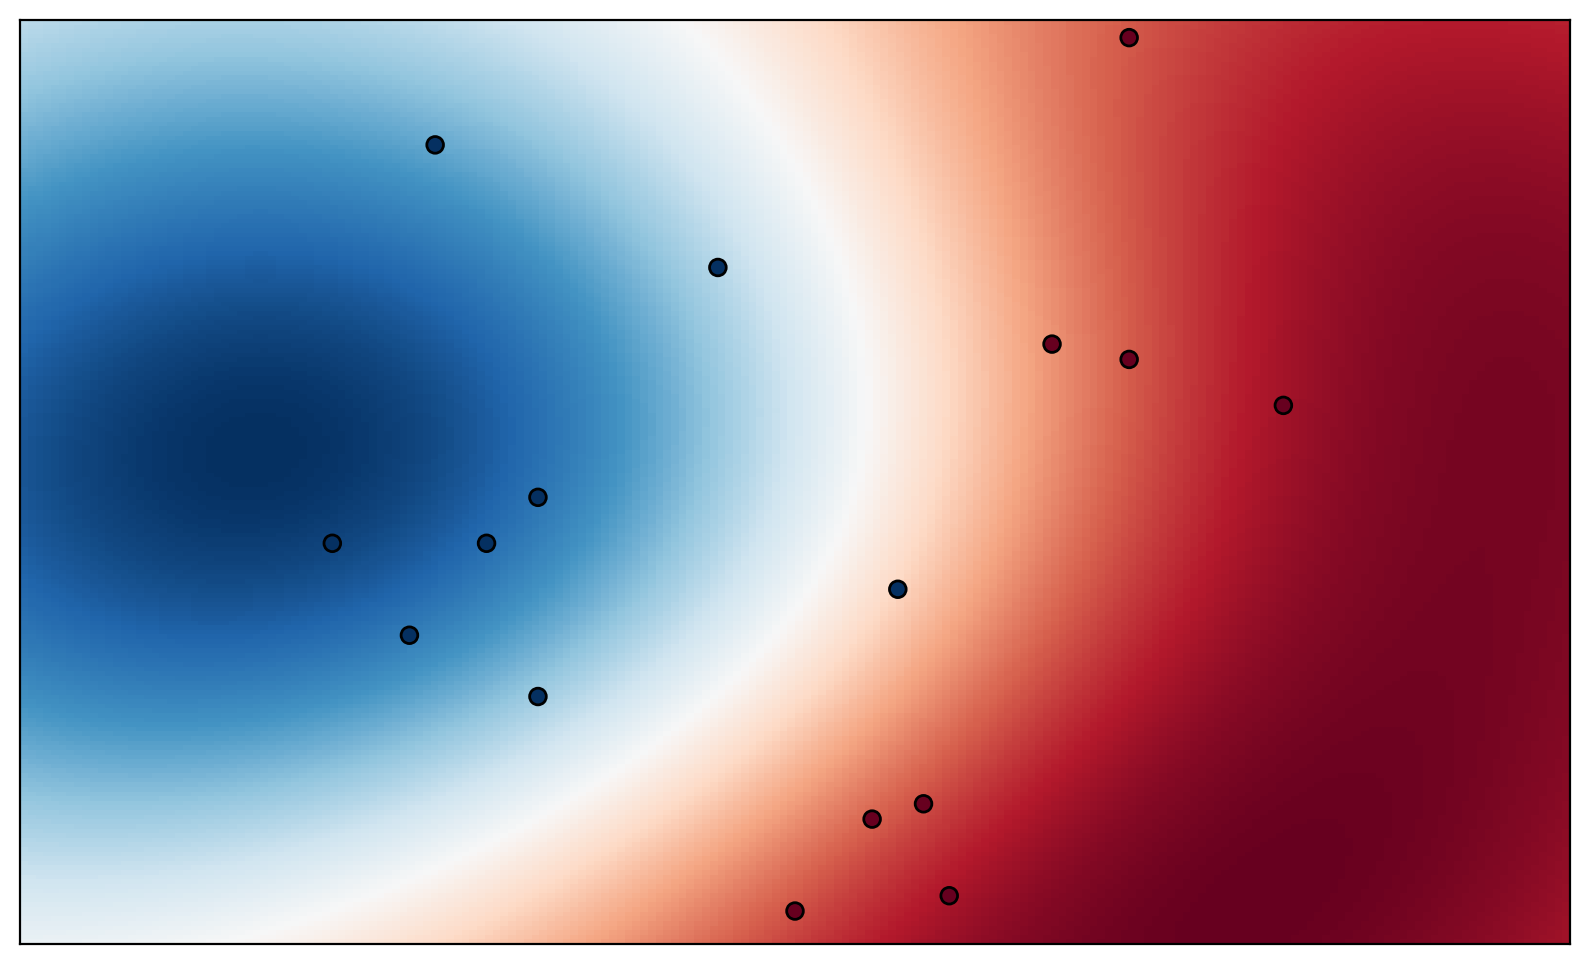

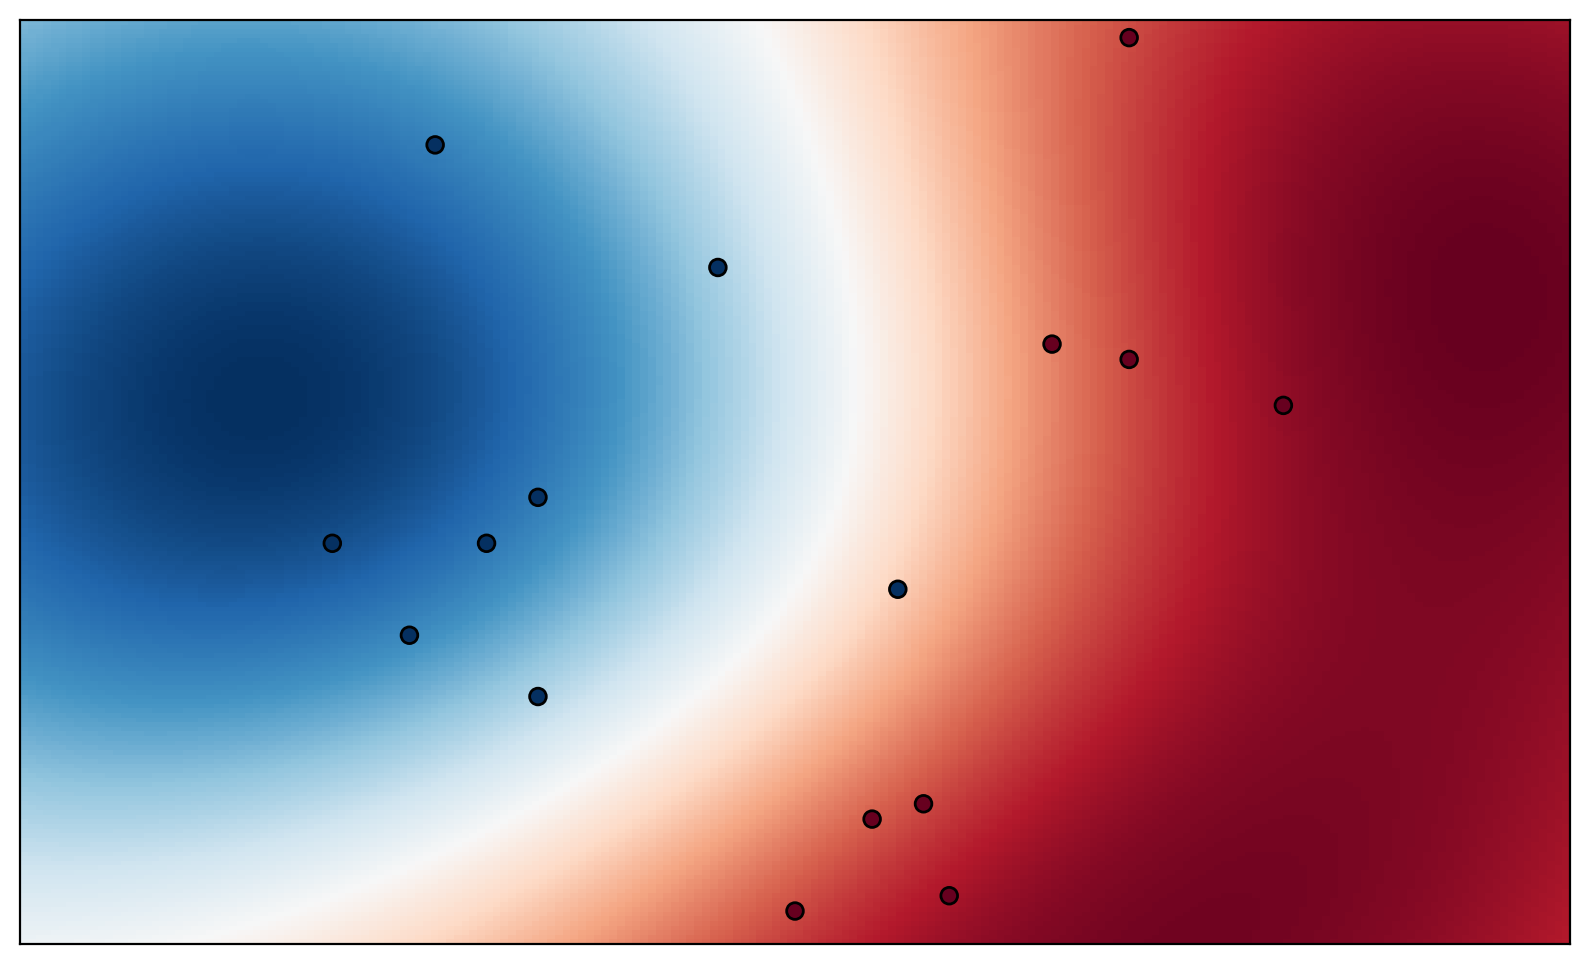

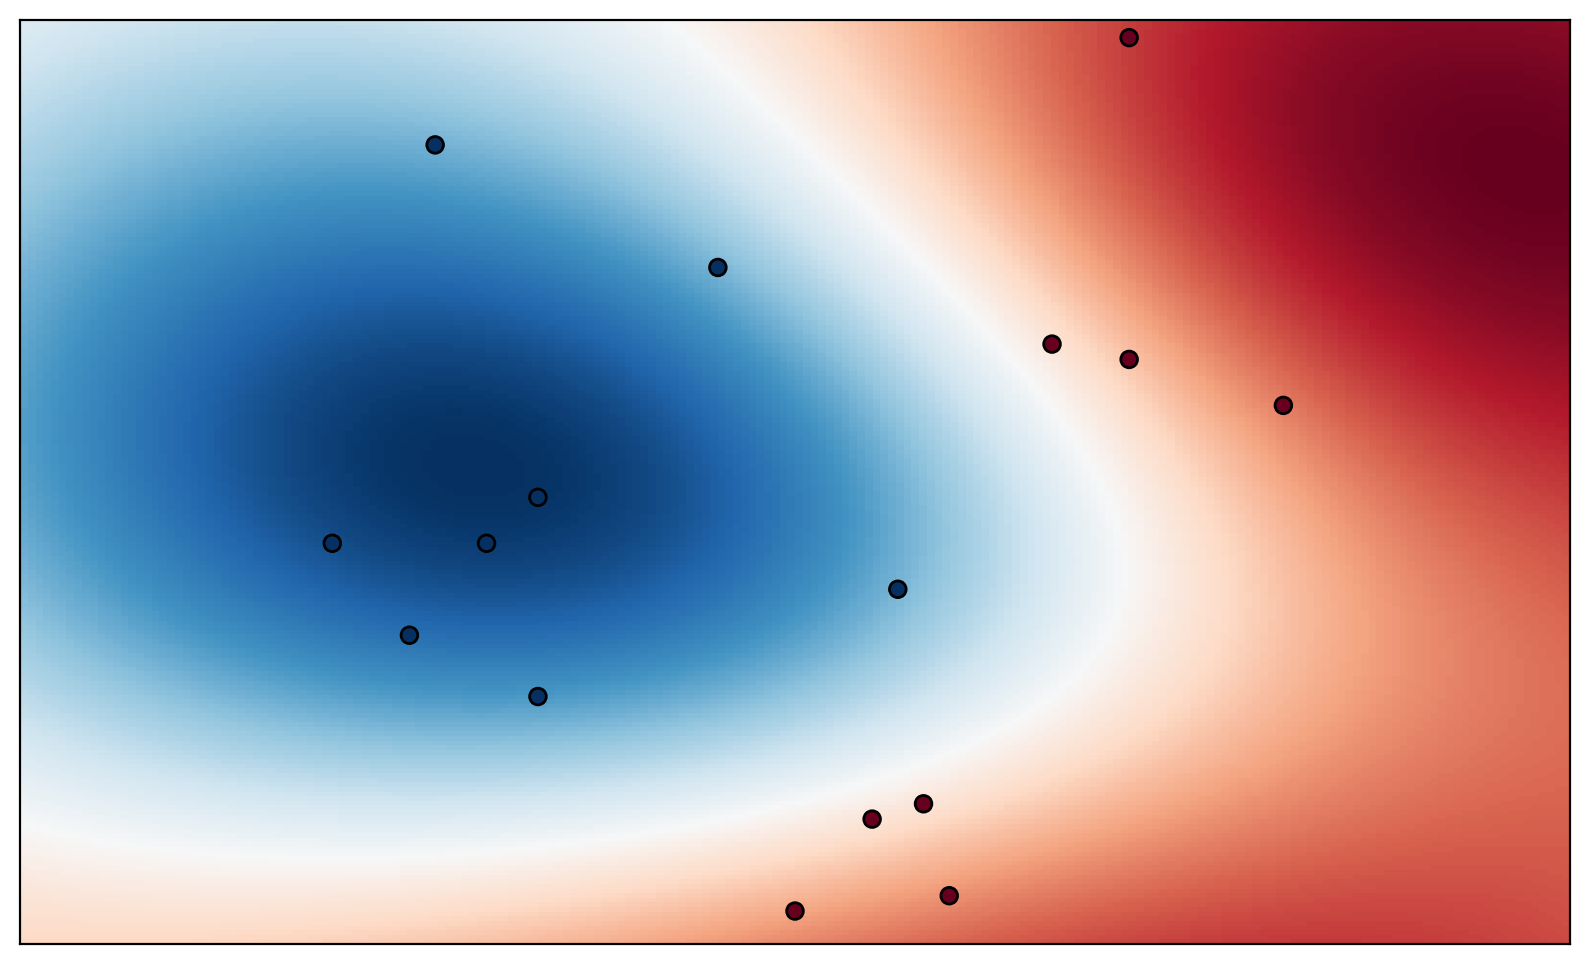

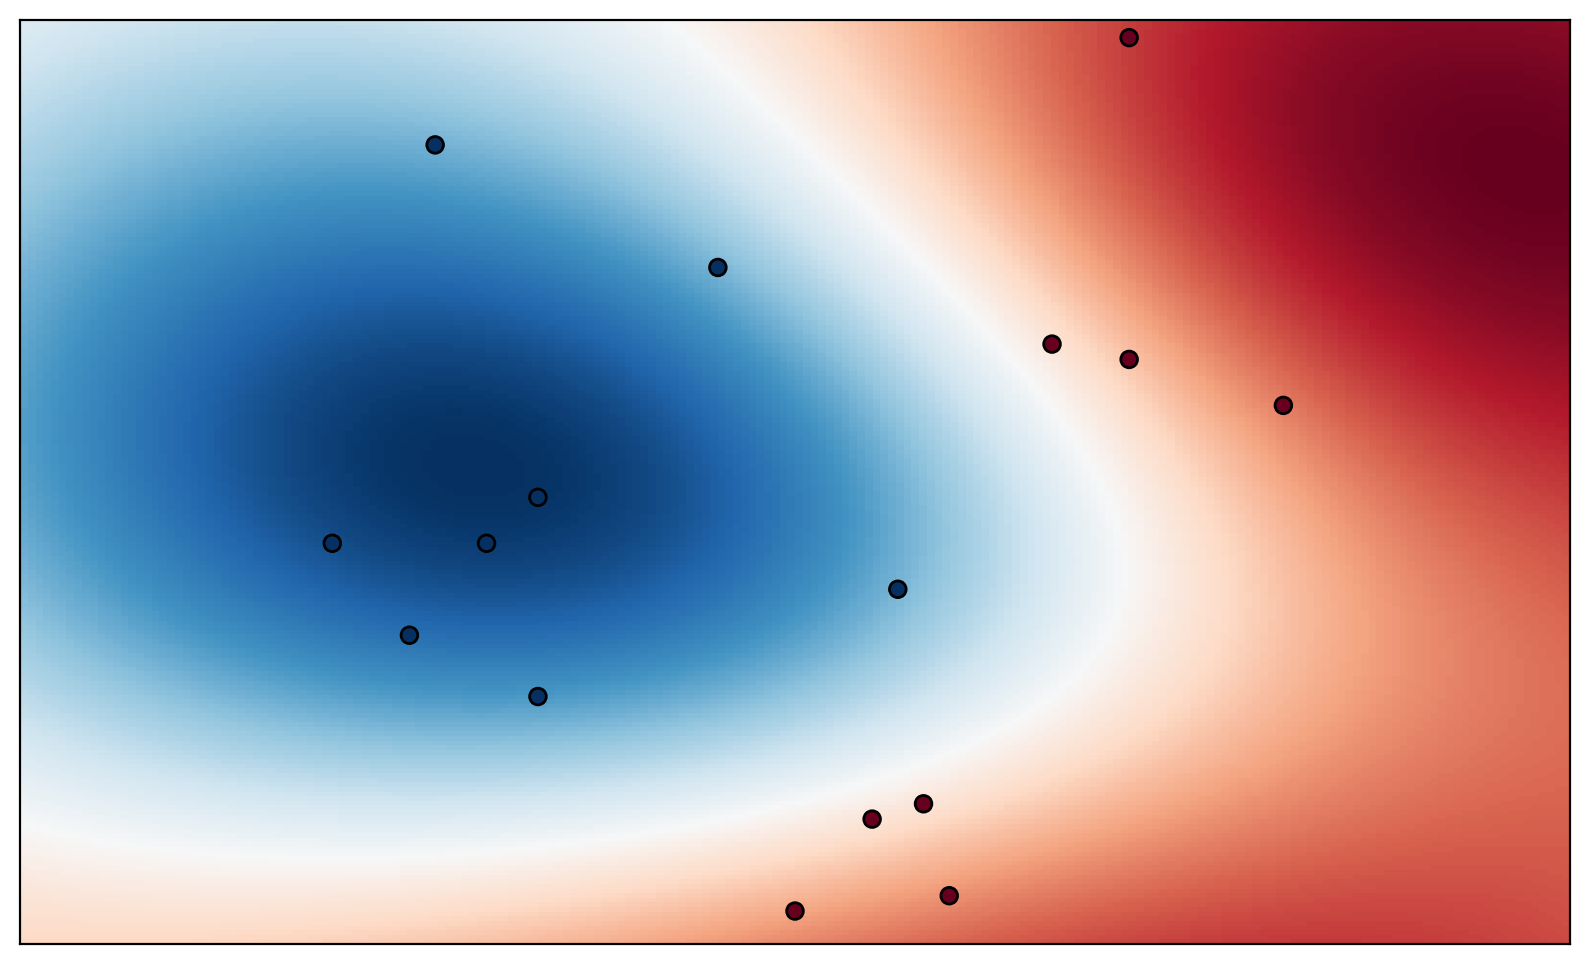

In [33]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 5))
count = 0
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
for k, (C, gamma, clf) in enumerate(classifiers):
    # evaluate decision function in a grid
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # visualize decision function for these parameters
    # plt.subplot(len(gamma_2d_range), len(C_2d_range), k + 1)
    plt.figure(figsize=(10, 6))
    # plt.title("C=10^%d" % (np.log10(C)), size="medium")

    # visualize parameter's effect on decision function
    plt.pcolormesh(xx, yy, -Z, cmap=plt.cm.RdBu)
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=plt.cm.RdBu_r, edgecolors="k")
    plt.xticks(())
    plt.yticks(())
    plt.axis("tight")
    plt.savefig(generateFilePath(f"SVM_params{count}"), bbox_inches='tight', dpi=200);
    count += 1